In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", temperature=0.2 
)

In [4]:
# Define State
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str

In [5]:
def generate_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"Generate an outline for the blog titled {title}. keep the outline simple and concise. keep it under 100 words"

    outline = llm.invoke(prompt).content

    state['outline'] = outline

    return state


def generate_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f"Generate an Blog for the title {title} and outline {outline}. keep the blog concise. keep it under 100 words"

    blog = llm.invoke(prompt).content

    state['blog'] = blog 

    return state



In [7]:
graph = StateGraph(BlogState)

graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)

# edges
graph.add_edge(START, 'generate_outline')
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge( "generate_blog", END)

workflow = graph.compile()

In [8]:
initial_state = {
    'title': "The Rich History of Yamen"
}

final_state = workflow.invoke(initial_state)

final_state['blog']

'## The Rich History of Yemen\n\nYemen, an ancient "cradle of civilization," boasts a profound history. It was home to the legendary Sabaean Kingdom, famed for the Queen of Sheba and the Marib Dam, and the powerful Himyarites.\n\nYemen embraced Islam early, fostering local dynasties. Later, Ottoman and British influences shaped its path. Today, its unique culture, stunning architecture, and resilient spirit endure. Yemen\'s rich past continues to define this remarkable land, a testament to its enduring historical importance.'

In [10]:
final_state['outline']

'Here\'s a simple and concise outline:\n\n**Blog Title: The Rich History of Yemen**\n\n*   **I. Introduction:**\n    *   Yemen: An ancient land, "cradle of civilization."\n    *   Brief overview of its profound historical significance.\n*   **II. Ancient Kingdoms:**\n    *   Sabaean Kingdom (Queen of Sheba, Marib Dam).\n    *   Himyarite Kingdom (pre-Islamic power).\n*   **III. Islamic Era:**\n    *   Early adoption of Islam.\n    *   Rise of local dynasties.\n*   **IV. External Influences:**\n    *   Ottoman and British presence.\n*   **V. Enduring Legacy:**\n    *   Unique culture, architecture, and resilience.\n*   **VI. Conclusion:**\n    *   Summarize Yemen\'s enduring historical importance.'

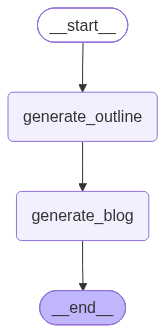

In [9]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())